In [1]:
import numpy as np
import matplotlib.pyplot as pl
from five_vec import five_vec
import finufft

In [2]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

In [3]:
def t_max_calc(f0, beta, f_max):
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

def f_calc(f0, beta, t):
    return f0*(1-8/3*beta*t)**(-3/8)

In [4]:
def nufft(beta, data, t, bin_no):
    bins = np.arange(bin_no) - bin_no//2

    tau = -3/5*(1-8/3*beta*t)**(5/8)/beta
    scale = (2*pi)/(tau[-1]-tau[0])
    tau *= scale
    start_diff = -pi-tau[0]
    tau += start_diff
    nufft_amp = finufft.nufft1d1(
        tau.astype(np.float64), data.astype(complex), bin_no, eps=1e-12, upsampfac=2.0)/len(data)
    nufft_freq = -bins*scale/(2*pi)
    nufft_power = np.abs(nufft_amp)**2
    return nufft_freq, nufft_amp

In [5]:
f0 = 30
Mc = 3e-2 * 2e30
f_max = 200
side_day = 1e4/3 #86164.09053083288
n_days = 3
T_obs = n_days*side_day
beta = const*f0**(8/3)*Mc**(5/3)
f_signal = 3*f_max
nt = round(f_signal*T_obs)
t = (np.arange(nt)/f_signal).astype(np.longdouble)

phi = -6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
freq_signal = 1*np.exp(1j*phi)

(29.997, 30.003)

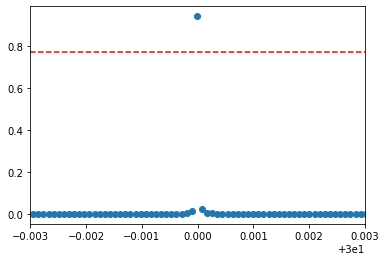

In [6]:
# Verify freq evolution is correct
nufft_freq, nufft_amp = nufft(beta, freq_signal, t, len(freq_signal))
pl.plot(nufft_freq, abs(nufft_amp)**2, 'o')
pl.axhline(2.4306/pi, c='r', ls='--')
pl.xlim(f0-0.003, f0+0.003)

In [7]:
f = f_calc(f0, beta, t)
d = 8e3*3.086e+16 # 8kpc
h0 = 4/d*(G*Mc/c**2)**(5/3)*(pi*f/c)**(2/3)

In [8]:
params = dict(ra = 0.5, dec = 0.5, eta = 0.5, psi = 0.5, lat = 0.5, 
              lng = 0.5, az = 0.5, side_day=side_day)
sidereal = five_vec(**params)
sidereal.compute_H()
sidereal.compute_A(t)
sidereal.compute_5vec()
amp_modulation = sidereal.amp_modulation

sys:1: ResourceWarning: unclosed socket <zmq.Socket(zmq.PUSH) at 0x7f4e10c5dd70>


In [14]:
signal = amp_modulation*freq_signal # * h0

fft_freqs, fft_amps = nufft(beta, signal, t, len(signal))
f0_idx = abs(fft_freqs-f0).argmin()

In [15]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

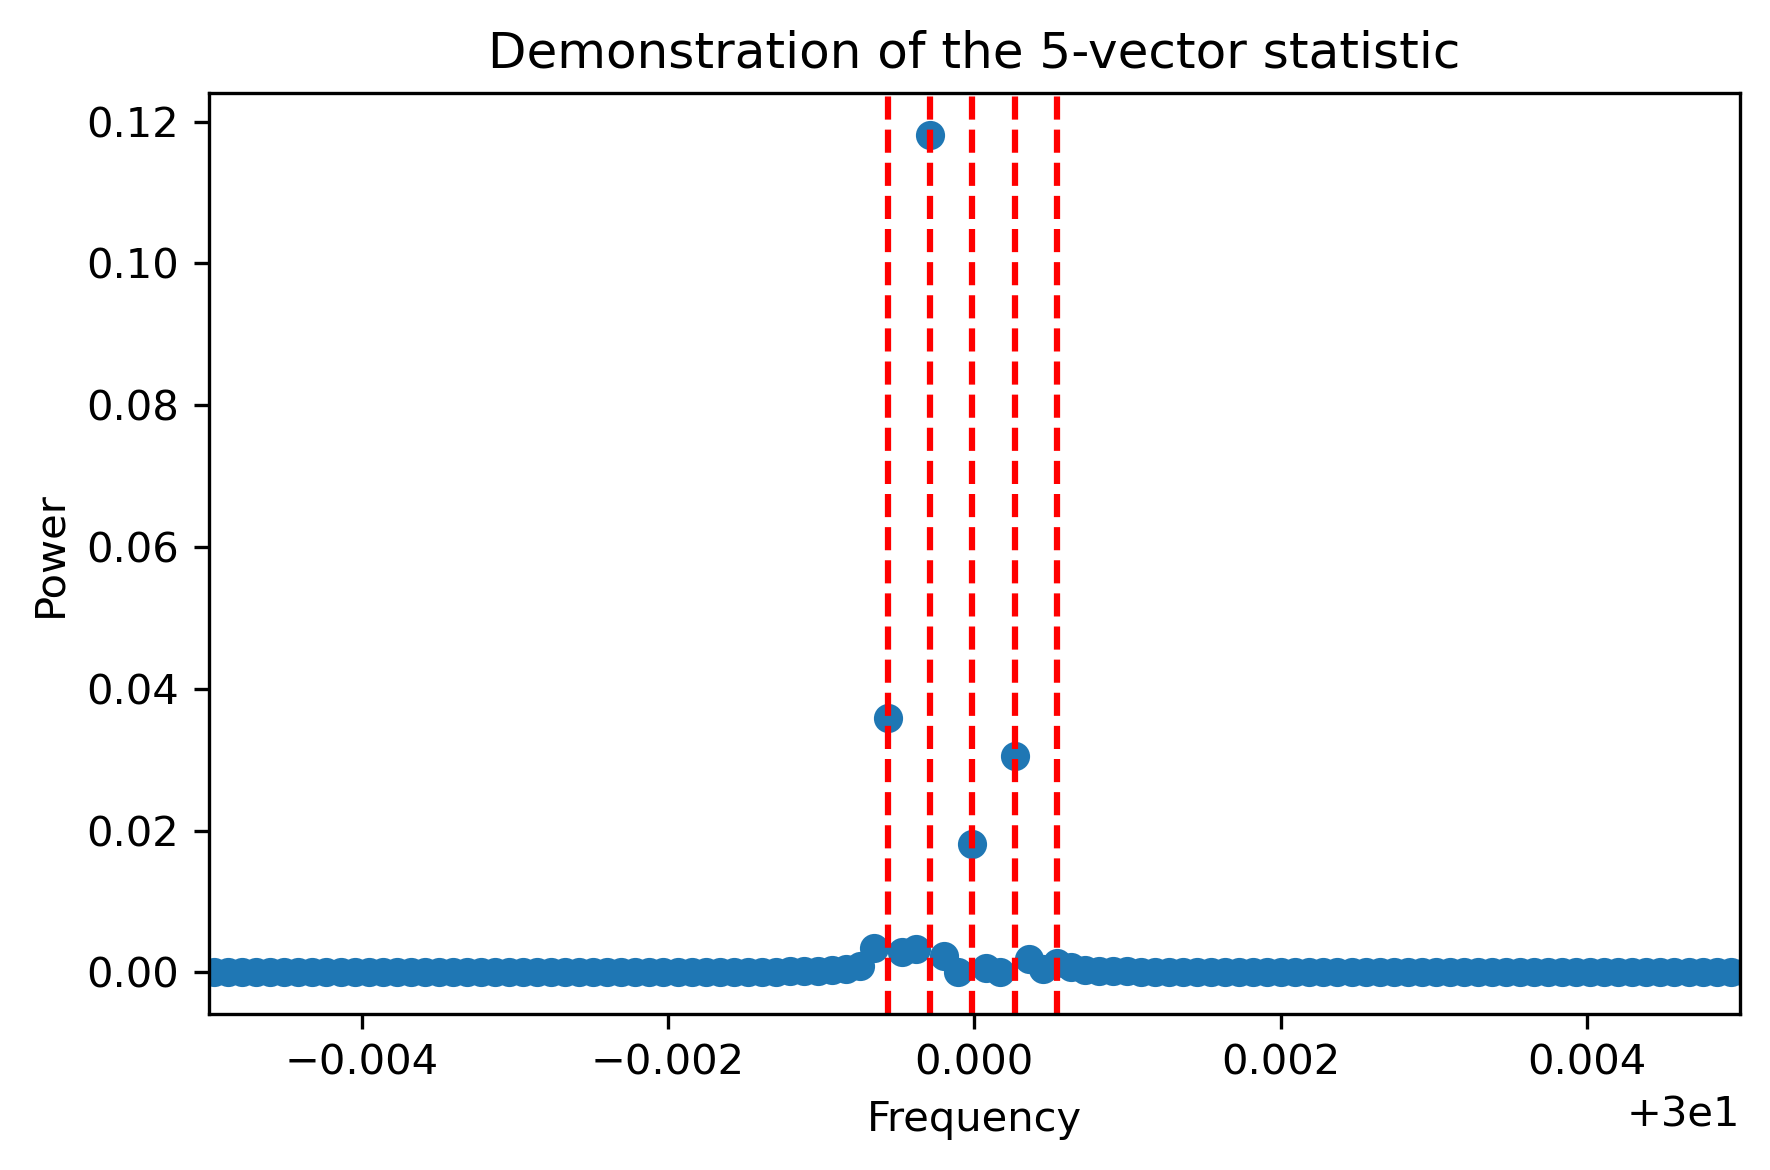

In [16]:
pl.plot(fft_freqs, abs(fft_amps)**2, 'o')
pl.xlim(f0-0.005, f0+0.005)
pl.axvline(fft_freqs[f0_idx-2*n_days], c='r', ls='--')
pl.axvline(fft_freqs[f0_idx-1*n_days], c='r', ls='--')
pl.axvline(fft_freqs[f0_idx], c='r', ls='--')
pl.axvline(fft_freqs[f0_idx+1*n_days], c='r', ls='--')
pl.axvline(fft_freqs[f0_idx+2*n_days], c='r', ls='--')
pl.xlabel("Frequency")
pl.ylabel("Power")
pl.title("Demonstration of the 5-vector statistic")
pl.tight_layout()

In [17]:
X = np.empty((5), dtype=complex)

f0_idx = abs(fft_freqs-f0).argmin()
X[0] = fft_amps[f0_idx-6]
X[1] = fft_amps[f0_idx-3]
X[2] = fft_amps[f0_idx]
X[3] = fft_amps[f0_idx+3]
X[4] = fft_amps[f0_idx+6]

In [21]:
estimator = abs(np.dot(X, np.conj(sidereal.A))/np.sum(np.abs(sidereal.A)**2))
estimator

0.35175720603549804

In [23]:
estimator

0.35175720603549804

Text(0, 0.5, 'h0')

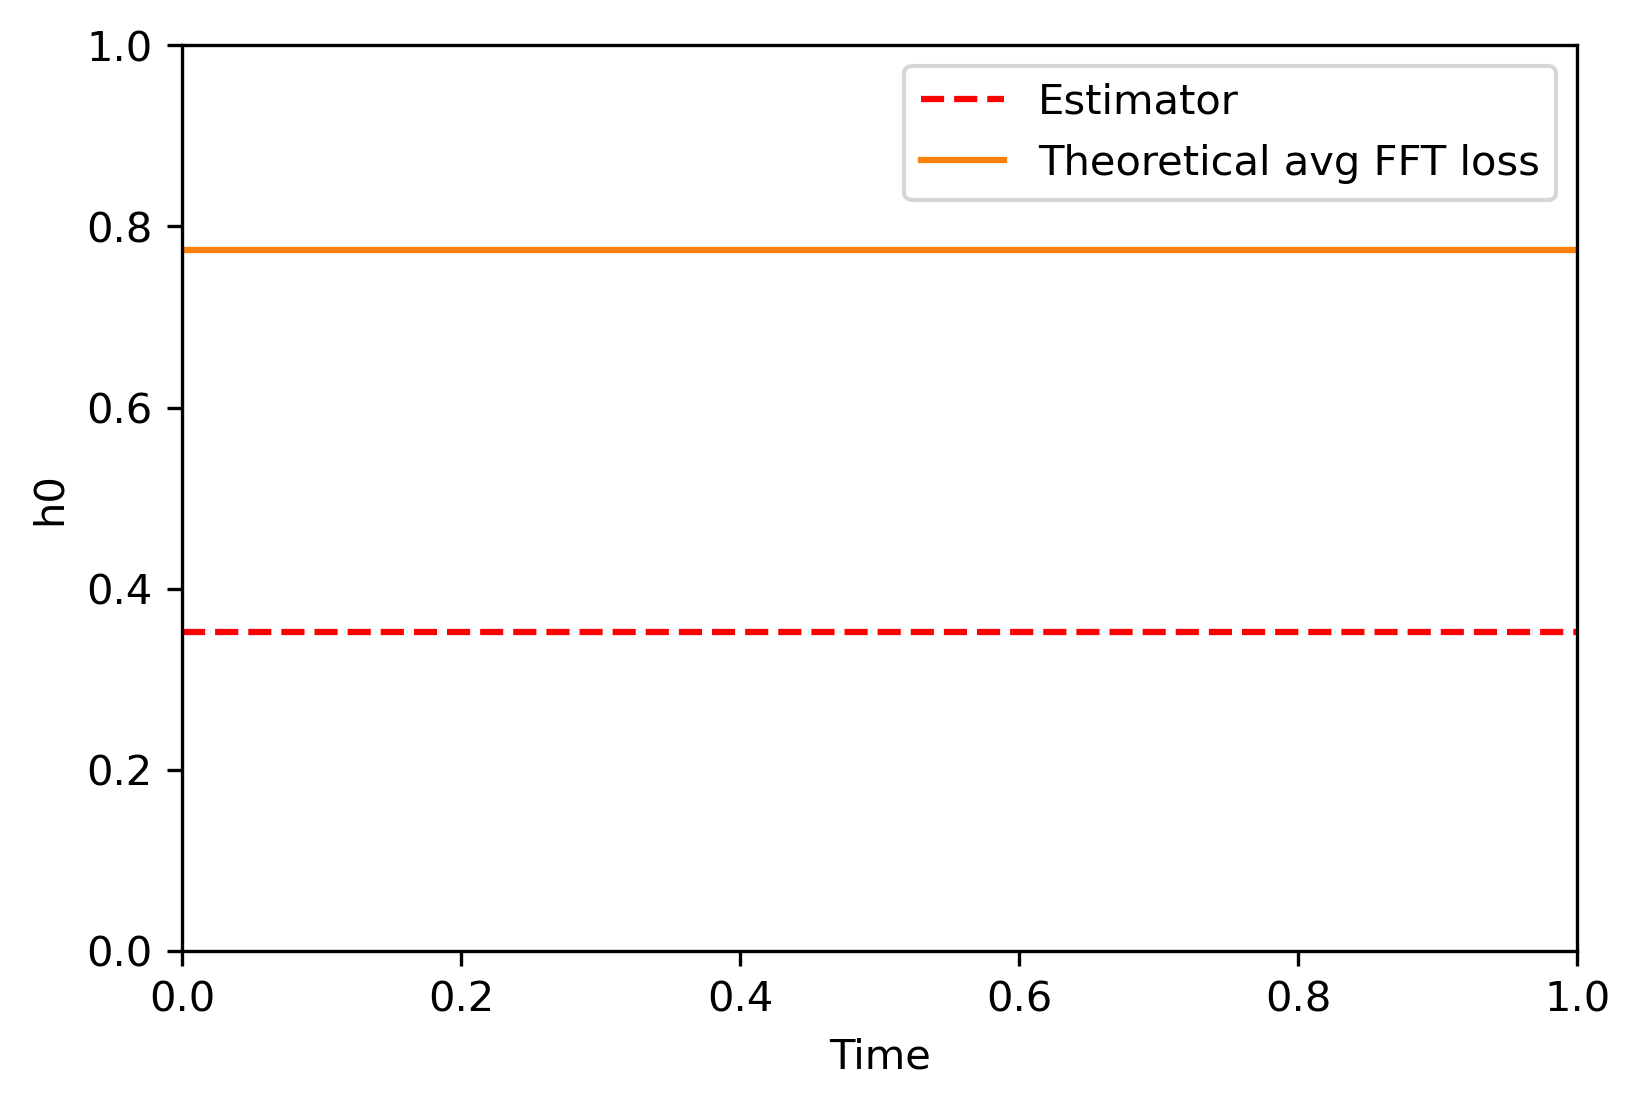

In [24]:
# pl.plot(t[::100], h0[::100])
pl.axhline(estimator, c='r', ls='--', label = 'Estimator')
pl.axhline(2.4306/pi, c='tab:orange', label="Theoretical avg FFT loss")
pl.legend()
pl.xlabel("Time")
pl.ylabel("h0")

In [14]:
2.4306/pi

0.7736840093583217

## Coverage test

In [25]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

f_max = 200
side_day = 1e4/3 #86164.09053083288
n_days = 3
T_obs = n_days*side_day
f_signal = 3*f_max
nt = round(f_signal*T_obs)
t = (np.arange(nt)/f_signal).astype(np.longdouble)
d = 8e3*3.086e+16 # 8kpc

params = dict(ra = 0.5, dec = 0.5, eta = 0.5, psi = 0.5, lat = 0.5, 
              lng = 0.5, az = 0.5, side_day=side_day)
sidereal = five_vec(**params)
sidereal.compute_H()
sidereal.compute_A(t)
sidereal.compute_5vec()
amp_modulation = sidereal.amp_modulation

In [34]:
nufft_results = []
fivevec_results=[]
for i in range(5):
    print(i)
    f0 = np.linspace(20, 40, 10, endpoint=False)[i]
    Mc = 3e-2 * 2e30
    beta = const*f0**(8/3)*Mc**(5/3)

    phi = -6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
    freq_signal = 1*np.exp(1j*phi)
    temp_freqs, temp_amps = nufft(beta, freq_signal, t, len(freq_signal))
    nufft_results.append(max(abs(temp_amps)**2))
    
    f = f_calc(f0, beta, t)
    h0 = 4/d*(G*Mc/c**2)**(5/3)*(pi*f/c)**(2/3)
    signal = h0[0]*amp_modulation*freq_signal

    fft_freqs, fft_amps = nufft(beta, signal, t, len(signal))
    f0_idx = abs(fft_freqs-f0).argmin()
    X = np.empty((5), dtype=complex)
    X[0] = fft_amps[f0_idx-n_days*2]
    X[1] = fft_amps[f0_idx-n_days*1]
    X[2] = fft_amps[f0_idx]
    X[3] = fft_amps[f0_idx+n_days*1]
    X[4] = fft_amps[f0_idx+n_days*2]
    
    estimator = abs(np.dot(X, np.conj(sidereal.A))/np.sum(np.abs(sidereal.A)**2))
    fivevec_results.append(estimator/h0[0])

0
1
2
3
4


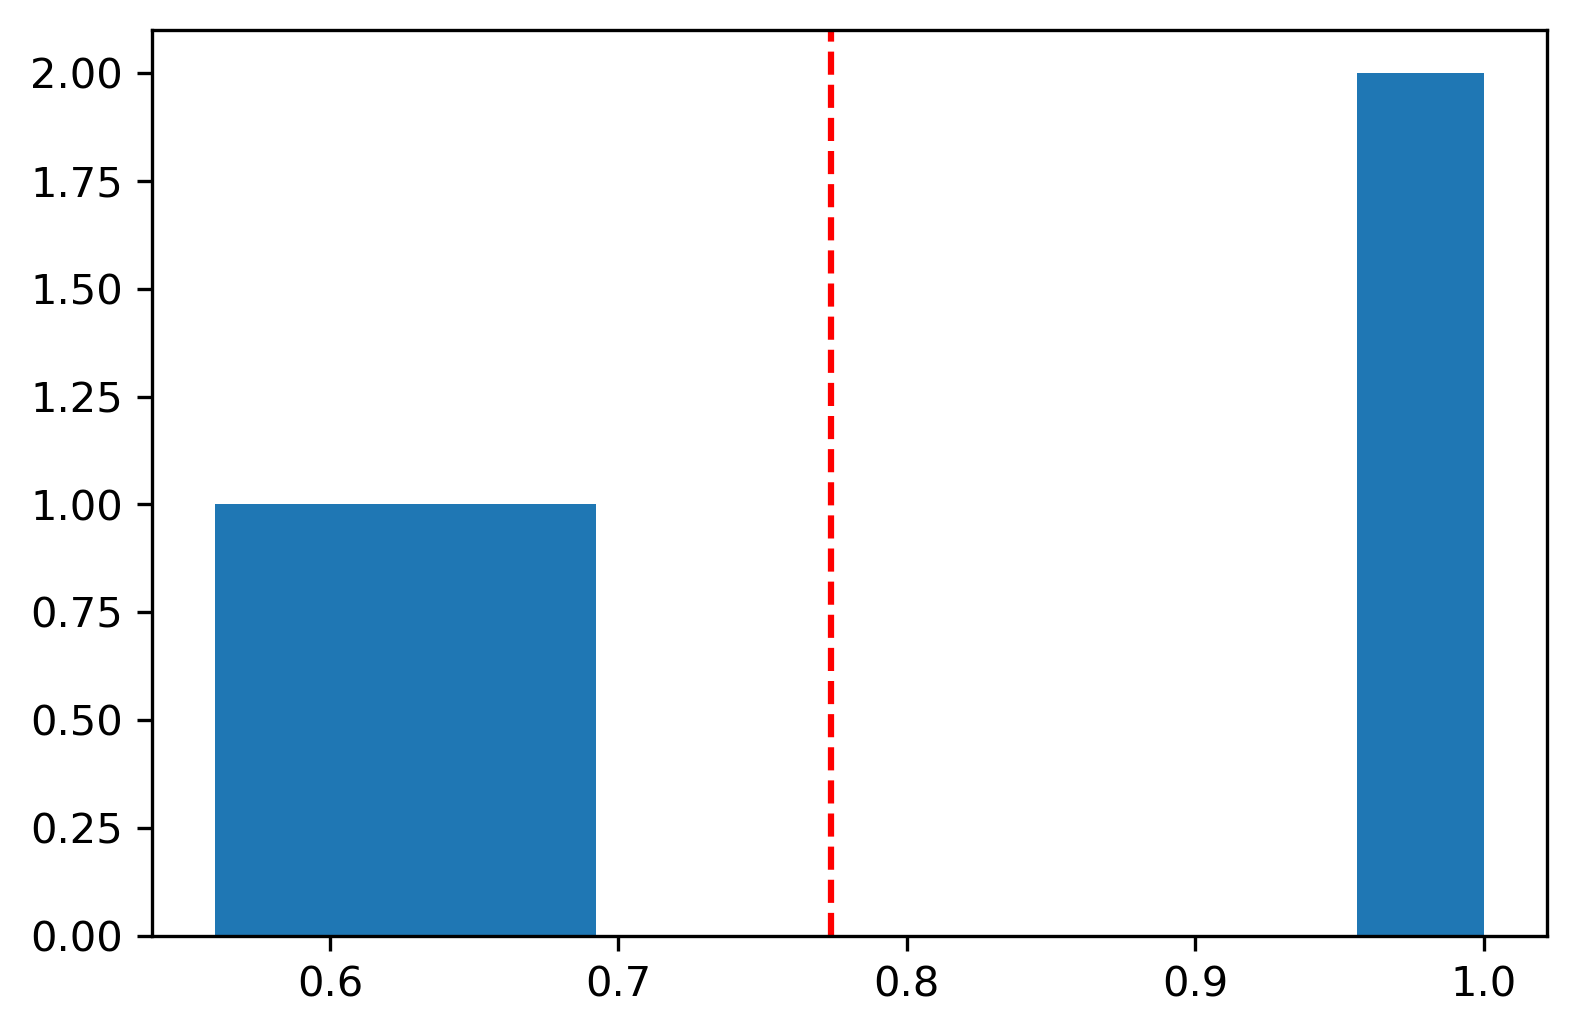

In [35]:
pl.hist(nufft_results)
pl.axvline(2.4306/pi, c='r', ls='--')

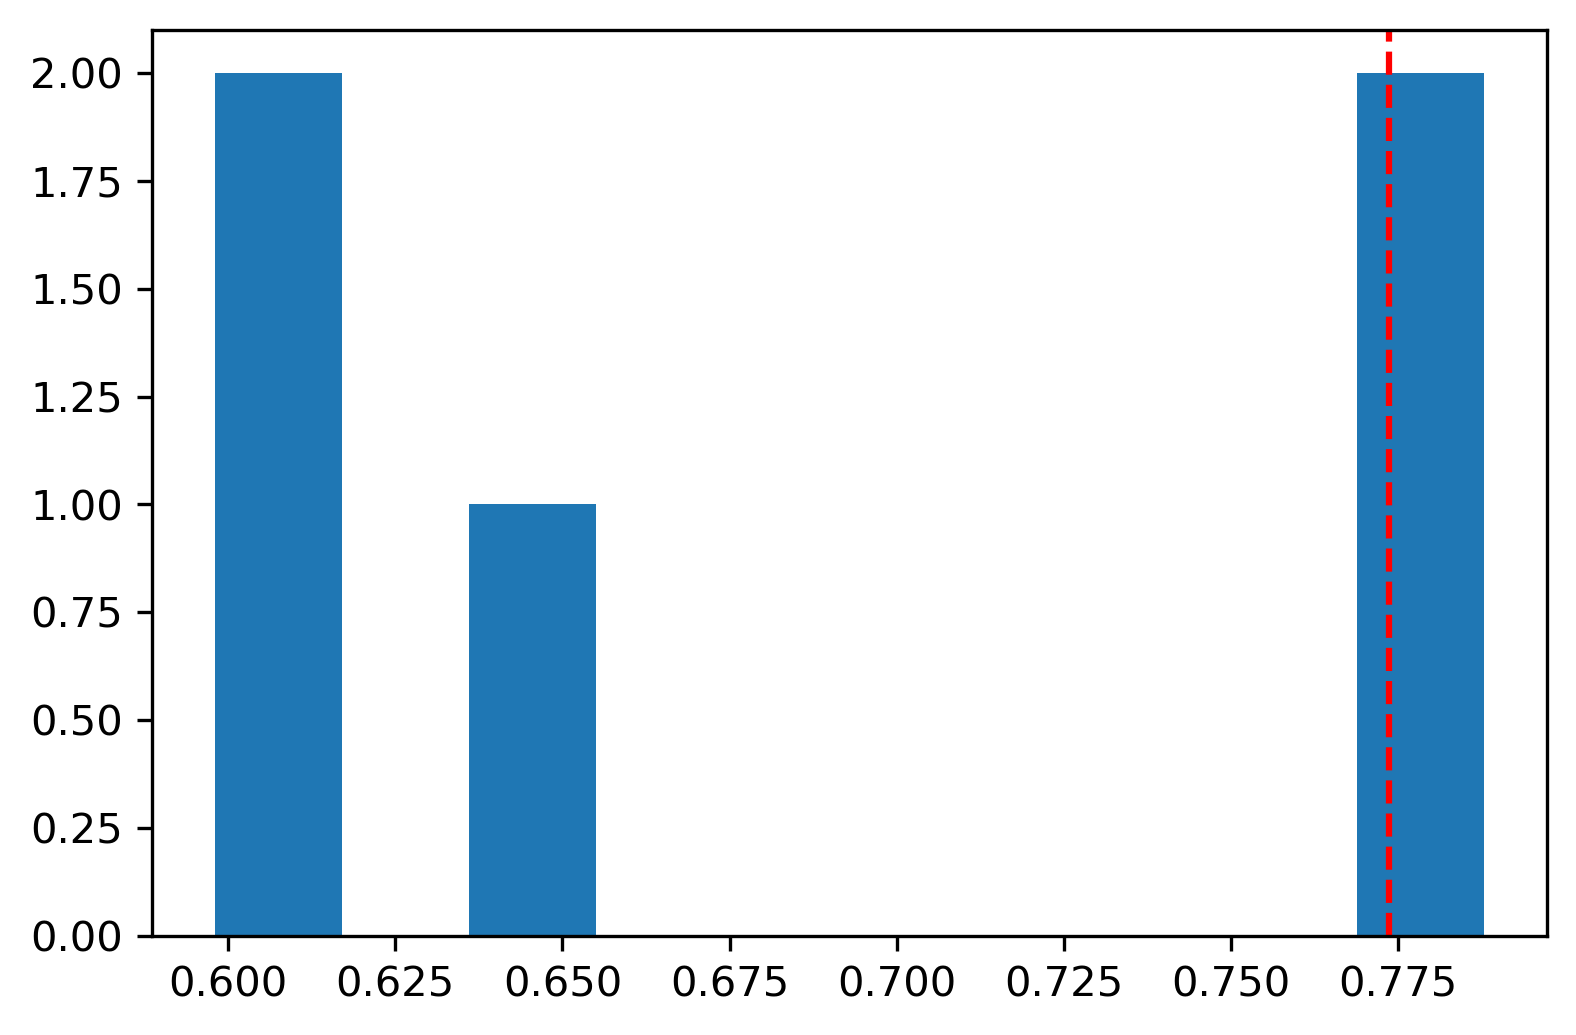

In [36]:
pl.hist(np.multiply(2, fivevec_results))
pl.axvline(2.4306/pi, c='r', ls='--')

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.41096469, 0.42255423, 0.43414376, 0.4457333 , 0.45732283,
        0.46891237, 0.4805019 , 0.49209144, 0.50368097, 0.51527051,
        0.52686004], dtype=float128),
 <BarContainer object of 10 artists>)

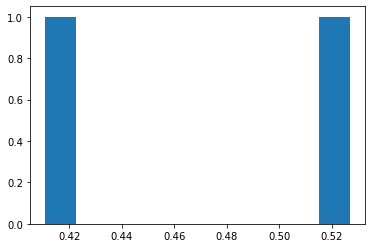

In [19]:
pl.hist(np.divide(fivevec_results,nufft_results))

## Additional loss from amp-modulation

In [6]:
f0 = 20
Mc = 4e-2 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)

f_max = 200
side_day = 1e4/3 #86164.09053083288
n_days = 3
T_obs = n_days*side_day
f_signal = 3*f_max
nt = round(f_signal*T_obs)
t = (np.arange(nt)/f_signal).astype(np.longdouble)
d = 8e3*3.086e+16 # 8kpc

# Amp modulation
params = dict(ra = 0.5, dec = 0.5, eta = 0.5, psi = 0.5, lat = 0.5, 
              lng = 0.5, az = 0.5, side_day=side_day)
sidereal = five_vec(**params)
sidereal.compute_H()
sidereal.compute_A(t)
sidereal.compute_5vec()
amp_modulation = sidereal.amp_modulation

In [7]:
phi = -6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
freq_signal = 1*np.exp(1j*phi)

#NUFFT
bin_no = len(freq_signal)
data=freq_signal
bins = np.arange(bin_no) - bin_no//2

tau = -3/5*(1-8/3*beta*t)**(5/8)/beta
scale = (2*pi)/(tau[-1]-tau[0])
tau *= scale
start_diff = -pi-tau[0]
tau += start_diff
temp_amp = finufft.nufft1d1(
    tau.astype(np.float64), data.astype(complex), bin_no, eps=1e-10, upsampfac=2.0)/len(data)
temp_freq = -bins*scale/(2*pi)

# amp modulation
f = f_calc(f0, beta, t)
h0 = 4/d*(G*Mc/c**2)**(5/3)*(pi*f/c)**(2/3)
signal = h0[0]*amp_modulation*freq_signal

# 5-vector
fft_freqs, fft_amps = nufft(beta, signal, t, len(signal))
f0_idx = abs(fft_freqs-f0).argmin()
X = np.empty((5), dtype=complex)
X[0] = fft_amps[f0_idx-n_days*2]
X[1] = fft_amps[f0_idx-n_days*1]
X[2] = fft_amps[f0_idx]
X[3] = fft_amps[f0_idx+n_days*1]
X[4] = fft_amps[f0_idx+n_days*2]

estimator = abs(np.dot(X, np.conj(sidereal.A))/np.sum(np.abs(sidereal.A)**2))

mono = 1*np.exp(1j*(2*pi*f0*t+phi[0]))
modulated_mono = h0[0]*amp_modulation*mono

In [8]:
inverse = finufft.nufft1d2(tau.astype(np.float64), fft_amps, eps=1e-12, upsampfac=2.0)

In [57]:
# test = np.fft.ifft(fft_amps*len(signal))

(-2.5e-23, 2.5e-23)

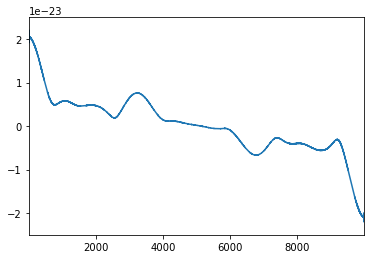

In [10]:
pl.plot(t, np.abs(inverse)-np.abs(signal))
pl.xlim(t[100], t[-100])
pl.ylim(-0.25e-22, 0.25e-22)

In [11]:
def strobo(beta, data, f_ratio):
    new_t = -3/5*(1-8/3*beta*t)**(5/8)/beta
    f_new = f_signal/f_ratio
    
    new_t *= f_new #changes the frequency to the new downsampled frequency (approximately, not exactly)
    floor_t = np.floor(new_t) #For some reason floor works better than round. Take it to the nearest time index which are integers
    idx = np.nonzero(np.diff(floor_t)) #The step that downsamples
    resampled = data[idx]
    t_out = (new_t[idx])/f_new
    return (resampled, t_out)

In [12]:
f0 = 20
Mc = 4e-2 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)

f_max = 200
n_days = 3
side_day = 1e4/n_days #86164.09053083288
T_obs = n_days*side_day
f_signal = 20*f_max
nt = round(f_signal*T_obs)
t = (np.arange(nt)/f_signal).astype(np.longdouble)
d = 8e3*3.086e+16 # 8kpc

# Amp modulation
params = dict(ra = 0.5, dec = 0.5, eta = 0.5, psi = 0.5, lat = 0.5, 
              lng = 0.5, az = 0.5, side_day=side_day)
sidereal = five_vec(**params)
sidereal.compute_H()
sidereal.compute_A(t)
sidereal.compute_5vec()
amp_modulation = sidereal.amp_modulation

In [34]:
phi = -6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
freq_signal = 1*np.exp(1j*phi)
# strobo_data, strobo_time = strobo(beta, freq_signal, f_ratio = 8)
# strobo_amp = np.fft.fftshift(np.fft.fft(strobo_data))
# strobo_freq = np.fft.fftshift(np.fft.fftfreq(len(strobo_data), np.diff(strobo_time)[0]))

# amp modulation
f = f_calc(f0, beta, t)
h0 = 4/d*(G*Mc/c**2)**(5/3)*(pi*f/c)**(2/3)
signal = h0[0]*amp_modulation*freq_signal

# # 5-vector
strobo_data, strobo_time = strobo(beta, signal, f_ratio = 8)
strobo_amp = np.fft.fftshift(np.fft.fft(strobo_data))/len(strobo_data)
strobo_freq = np.fft.fftshift(np.fft.fftfreq(len(strobo_data), np.diff(strobo_time)[0]))

f0_idx = abs(strobo_freq-f0).argmin()
X = np.empty((5), dtype=complex)
X[0] = strobo_amp[f0_idx-n_days*2]
X[1] = strobo_amp[f0_idx-n_days*1]
X[2] = strobo_amp[f0_idx]
X[3] = strobo_amp[f0_idx+n_days*1]
X[4] = strobo_amp[f0_idx+n_days*2]

estimator = abs(np.dot(X, np.conj(sidereal.A))/np.sum(np.abs(sidereal.A)**2))

# mono = 1*np.exp(1j*(2*pi*f0*t+phi[0]))
# modulated_mono = h0[0]*amp_modulation*mono

In [28]:
# pl.plot(strobo_freq, abs(strobo_amp/len(strobo_data))**2, 'o')
# pl.axhline(2.4306/pi, c='r', ls='--')
# pl.xlim(f0-0.003, f0+0.003)

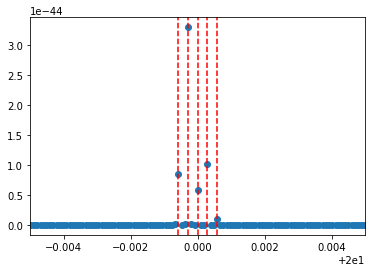

In [35]:
pl.plot(strobo_freq, abs(strobo_amp)**2, 'o')
pl.xlim(f0-0.005, f0+0.005)
pl.axvline(strobo_freq[f0_idx-2*n_days], c='r', ls='--')
pl.axvline(strobo_freq[f0_idx-1*n_days], c='r', ls='--')
pl.axvline(strobo_freq[f0_idx], c='r', ls='--')
pl.axvline(strobo_freq[f0_idx+1*n_days], c='r', ls='--')
pl.axvline(strobo_freq[f0_idx+2*n_days], c='r', ls='--')

In [36]:
estimator/h0[0]

0.98424002007233075793